<a href="https://colab.research.google.com/github/2326-aar/Task-3/blob/main/House_price_task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']
Missing values:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Simple Linear Regression Evaluation:
MAE: 1474748.13
MSE: 3675286604768.19
R²: 0.273

Multiple Linear Regression Evaluation:
MAE: 970043.40
MSE: 1754318687330.66
R²: 0.653


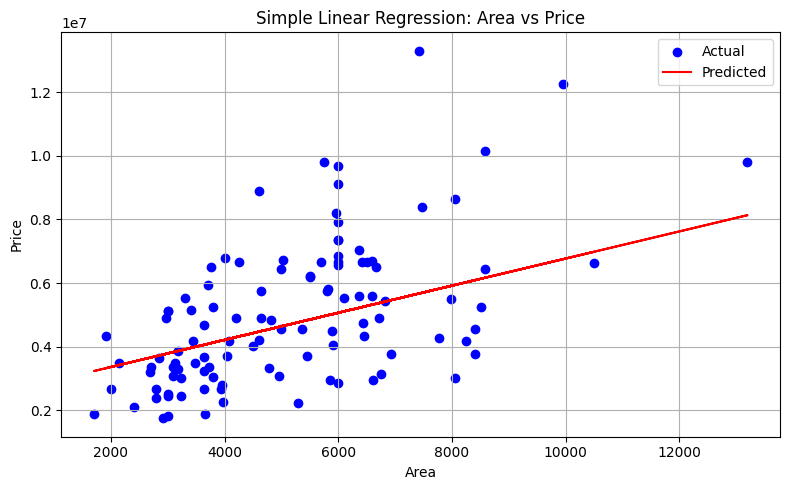

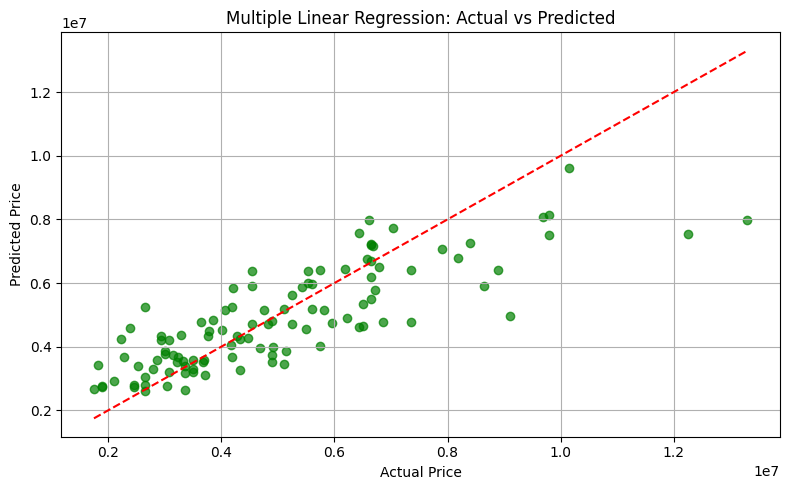

In [5]:
# Task 3: Simple and Multiple Linear Regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("/content/Housing.csv.csv")

# Display basic info
print("Columns:", df.columns.tolist())
print("Missing values:\n", df.isnull().sum())

# Encode categorical columns
categorical = df.select_dtypes(include='object').columns.tolist()
df = pd.get_dummies(df, columns=categorical, drop_first=True)

# ----------- SIMPLE LINEAR REGRESSION (using 'area') -----------
X_simple = df[['area']]
y = df['price']
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y, test_size=0.2, random_state=42)

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)
y_pred_simple = simple_model.predict(X_test_s)

# ----------- MULTIPLE LINEAR REGRESSION (using all features) -----------
X = df.drop('price', axis=1)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X, y, test_size=0.2, random_state=42)

multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)
y_pred_multi = multi_model.predict(X_test_m)

# ----------- EVALUATION FUNCTION -----------
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{model_name} Evaluation:")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"R²: {r2:.3f}")
    return {'MAE': mae, 'MSE': mse, 'R2': r2}

# Evaluate both models
eval_simple = evaluate_model(y_test_s, y_pred_simple, "Simple Linear Regression")
eval_multi = evaluate_model(y_test_m, y_pred_multi, "Multiple Linear Regression")

# ----------- PLOTS -----------
# Plot: Simple Linear Regression
plt.figure(figsize=(8, 5))
plt.scatter(X_test_s, y_test_s, color='blue', label='Actual')
plt.plot(X_test_s, y_pred_simple, color='red', label='Predicted')
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Simple Linear Regression: Area vs Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("simple_regression_plot.png")
plt.show()

# Plot: Multiple Linear Regression (Predicted vs Actual)
plt.figure(figsize=(8, 5))
plt.scatter(y_test_m, y_pred_multi, alpha=0.7, color='green')
plt.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Multiple Linear Regression: Actual vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.savefig("multiple_regression_plot.png")
plt.show()
